# EDA scratch — find good demo examples (read-only)

Explore the curated **TextVQA** Lance subset and surface image / question / answer
examples like the sugar-packet one, so you can pin a vetted shortlist before the workshop.

**No training, no prep — just scan the data and query it.** Run top-to-bottom.

In [1]:
# Minimal deps (Colab ships pandas/pillow/matplotlib; add polars + lance + hub).
# !pip -q install 'lancedb>=0.30' 'pylance>=0.18' 'huggingface_hub>=0.24' 'polars>=1.0' 2>/dev/null
# print('ok')

## Pull the curated subset from Hugging Face

The same data the workshop uses — [`lance-format/textvqa-lance-colab`](https://huggingface.co/datasets/lance-format/textvqa-lance-colab),
600 train / 400 val rows. We only read a subset of it below; the heavy precomputed columns
(`vision_tower_hiddens`, token ids) are ignored for EDA.

In [2]:
import os, lancedb, pyarrow as pa
from huggingface_hub import snapshot_download

HF_REPO = os.environ.get('TEXTVQA_COLAB_REPO', 'lance-format/textvqa-lance-colab')
local = snapshot_download(repo_id=HF_REPO, repo_type='dataset', local_dir='data/eda')

def open_tbl(path):
    name = os.path.basename(path)
    name = name[:-len('.lance')] if name.endswith('.lance') else name
    return lancedb.connect(os.path.dirname(path)).open_table(name)

train_tbl = open_tbl(f'{local}/textvqa_colab_train.lance')
val_tbl   = open_tbl(f'{local}/textvqa_colab_val.lance')

# question_id may be int or string — build a type-safe filter helper for later cells.
_QID_STR = pa.types.is_string(train_tbl.schema.field('question_id').type)
def qid_pred(q):
    return f"question_id = '{q}'" if _QID_STR else f'question_id = {q}'

print('train:', train_tbl.count_rows(), '| val:', val_tbl.count_rows())
print('columns:', train_tbl.schema.names)

/Users/prrao/code/tmls-2026-demo/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 21 files: 100%|██████████| 21/21 [00:00<00:00, 1644.21it/s]

train: 600 | val: 400
columns: ['id', 'image', 'image_id', 'question_id', 'question', 'answers', 'answer', 'image_emb', 'question_emb', 'ocr_tokens', 'image_classes', 'set_name', 'vision_tower_hiddens', 'input_ids', 'attention_mask', 'labels']


## Visualize one example

Render a single row the way the workshop notebook shows samples — image + question +
answer + the OCR text read off it. `ROW = 4` is the Hanoi junkyard scene; change it to
preview any other row.


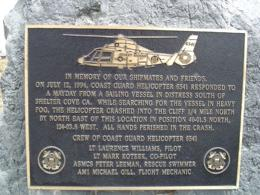

In [3]:
import io, base64
from PIL import Image
from IPython.display import HTML, display

def thumb(img_bytes, size=260):
    im = Image.open(io.BytesIO(img_bytes)).convert('RGB'); im.thumbnail((size, size))
    buf = io.BytesIO(); im.save(buf, 'JPEG')
    return base64.b64encode(buf.getvalue()).decode()

ROW = 4   # the Hanoi junkyard scene — change to preview any other row
s = (train_tbl.search().select(['image', 'question', 'answer', 'ocr_tokens'])
     .limit(ROW + 1).to_arrow().to_pylist()[ROW])
display(HTML(
    '<div style="text-align:center;font-size:13px">'
    f'<img src="data:image/jpeg;base64,{thumb(s["image"])}" width=260><br>'
    f'<b>{s["question"]}</b><br>answer: {s["answer"]}<br>'
    f'<span style="color:#888">ocr: {" ".join((s["ocr_tokens"] or [])[:10])}</span></div>'
))

## A light metadata frame

Project only the columns we need — image bytes, embeddings, and hidden states stay on disk.
There's no `ocr_token_count` column in this table, so we derive `ocr_len` from the token list.

In [4]:
import polars as pl

EDA_COLS = ['question_id', 'question', 'answer', 'ocr_tokens', 'image_classes']
EDA_COLS = [c for c in EDA_COLS if c in train_tbl.schema.names]
df = (train_tbl.search().select(EDA_COLS).limit(train_tbl.count_rows()).to_polars()
      .with_columns(ocr_len=pl.col('ocr_tokens').list.len()))
print(df.shape)
df.head()

(600, 6)


question_id,question,answer,ocr_tokens,image_classes,ocr_len
str,str,str,list[str],list[str],u32
"""129""","""what airline did these sugar p…","""twa""","[""7h"", ""the"", … ""Instant""]","[""Book"", ""Vehicle"", … ""Aircraft""]",18
"""130""","""what is the brand name of suga…","""domino""","[""7h"", ""the"", … ""Instant""]","[""Book"", ""Vehicle"", … ""Aircraft""]",18
"""192""","""what is the copyright date?""","""1975""","[""(PAR-5"", "")HANOI"", … ""975""]","[""Train"", ""Book"", … ""Aircraft""]",48
"""193""","""what is this a picture of?""","""junkyard at hue""","[""(PAR-5"", "")HANOI"", … ""975""]","[""Train"", ""Book"", … ""Aircraft""]",48
"""230""","""who is this in memory of?""","""our shipmates and friends""","[""IN"", ""MEMORY"", … ""MECHANIC""]","[""Vehicle"", ""Wheel"", … ""Aircraft""]",87


## Angle 1 — the answer is text *in* the image (the sugar-packet pattern)

Let's first look for rows where the answer appears in the OCR tokens — this means guaranteed "read the image" cases.
The results are ranked by how text-dense the image is (`ocr_len`).

In [5]:
reads = (
    df.with_columns(
        _ans=pl.col('answer').str.strip_chars().str.to_lowercase(),
        _ocr=pl.col('ocr_tokens').list.eval(pl.element().str.to_lowercase()),
    )
    .filter(pl.col('_ocr').list.contains(pl.col('_ans')))
    .sort('ocr_len', descending=True)
    .drop('_ans', '_ocr')
)
print(f'{reads.height} of {df.height} rows have the answer in the image text')
reads.select(['question_id', 'question', 'answer', 'ocr_len']).head(20)

160 of 600 rows have the answer in the image text


question_id,question,answer,ocr_len
str,str,str,u32
"""2166""","""what page number is this?""","""34""",84
"""2344""","""what is the title of the book?""","""demonized""",73
"""2325""","""who is full of eagerness to wo…","""garuda""",66
"""1712""","""what is the url?""","""preparewny.org""",65
"""1418""","""which senator is this addresse…","""simitian""",59
…,…,…,…
"""1502""","""what is the brand name of the …","""nathan's""",42
"""1929""","""what city is this book about?""","""hanoi""",42
"""1887""","""how much does it cost to atten…","""free""",41


## Angle 2 — scalar filter: text-dense scenes + reading-type questions

LanceDB can push the keyword filter down to the data layer. The `ocr_len > 15` is a predicate we can easily filter in LanceDB via SQL, or in Polars.

The query below checks for text-dense scenes (OCR token length > a threshold), and the question contains specific keywords of interest.

In [6]:
kw_sql = ("question LIKE '%brand%' OR question LIKE '%sign%' OR question LIKE '%name%' "
          "OR question LIKE '%logo%' OR question LIKE '%title%'")

hits = (train_tbl.search().where(kw_sql)
        .select(['question_id', 'question', 'answer', 'ocr_tokens']).to_polars())

(hits.with_columns(ocr_len=pl.col('ocr_tokens').list.len())
     .filter(pl.col('ocr_len') > 15)
     .select(['question_id', 'question', 'answer', 'ocr_len'])
     .head(25))

question_id,question,answer,ocr_len
str,str,str,u32
"""130""","""what is the brand name of suga…","""domino""",18
"""303""","""what is the name of the image?""","""color coded""",27
"""338""","""what is the name of the confer…","""size does matter""",26
"""489""","""what is the name of the one wi…","""desert attack""",55
"""524""","""what brand of building block i…","""lego""",25
…,…,…,…
"""1392""","""what brand is advertised?""","""milka""",18
"""1432""","""is this sign advertising the w…","""unanswerable""",24
"""1437""","""what is the website listed on …","""americasfirstregion.com""",24


## A note on indexes

The curated subset is just raw columns — **no prebuilt indexes** (`list_indices()`
is empty on a fresh pull). For a set this small the `WHERE ... LIKE` filter in
Angle 2 covers text search, so we don't build one here. At scale you'd add a
vector / FTS / scalar index, and Lance keeps it inside the dataset.

In [7]:
# This subset ships NO prebuilt indexes — list_indices() shows what's there.
for name, t in [('train', train_tbl), ('val', val_tbl)]:
    print(f'{name:6} indices: {t.list_indices()}')

# For a set this small, the WHERE ... LIKE filter (Angle 2) covers text search
# without building anything. At scale you'd add a vector / FTS / scalar index —
# and Lance stores it inside the dataset.

train  indices: [Index(FTS, columns=["question"], name="question_idx")]
val    indices: []


## 7 · Angle 3 — find visually similar images (vector search)

Angles 1–2 matched on *text* (the answer or the question). This one matches on the
*image itself*: we pick one example — the **seed** — and use its CLIP **image embedding**
(a vector that captures what the picture looks like) to pull the rows whose images look
most similar.

Below, the **seed** is on the left and its **top-3 nearest images** are on the right
(tagged with CLIP distance — smaller = more similar). Takeaway: once you've found one
example worth using, this fans out to a cluster of look-alikes — more packaging, more
street signs, more jerseys — without needing the right search keywords.

seedwhat page number is this?answer: 34,d=0.90who is full of eagerness to work?answer: garuda,d=0.90what is written in bold on the top of the left page?answer: gayatri mantra,"d=0.93what is the name of this book?answer: where to put the ""3 bottle bar"""

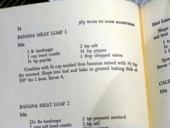
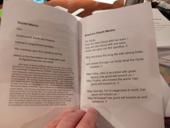
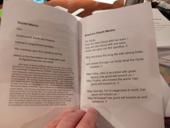
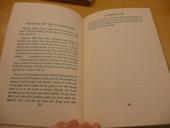

seed question_id: 2166


In [8]:
if 'image_emb' in train_tbl.schema.names:
    seed_qid = reads['question_id'][0]
    seed = (train_tbl.search().where(qid_pred(seed_qid))
            .select(['image', 'image_emb', 'question', 'answer']).limit(1).to_arrow().to_pylist()[0])
    hits = (train_tbl.search(seed['image_emb'], vector_column_name='image_emb')
            .select(['image', 'question', 'answer', 'question_id', '_distance'])
            .limit(4).to_arrow().to_pylist())
    hits = [h for h in hits if str(h['question_id']) != str(seed_qid)][:3]   # drop the seed itself

    def _card(img, tag, q, a):
        return ('<td style="text-align:center;font-size:11px;vertical-align:top;padding:6px">'
                f'<img src="data:image/jpeg;base64,{thumb(img, 170)}" width=170><br>'
                f'<span style="color:#e97852">{tag}</span><br>'
                f'<b>{q}</b><br>answer: {a}</td>')

    html = _card(seed['image'], 'seed', seed['question'], seed['answer'])
    html += ''.join(_card(h['image'], f"d={h['_distance']:.2f}", h['question'], h['answer']) for h in hits)
    display(HTML(f'<table><tr>{html}</tr></table>'))
else:
    print('no image_emb column in this table — skip vector search')